# Laboratorio 4 - Análisis de Datos Geoespaciales
## Avance: ejercicios 1 al 4

En este notebook se trabaja con imágenes Sentinel-2 para los lagos Atitlán y Amatitlán.

Repo: https://github.com/Ninaswiftie09/Data_Science/tree/Laboratorio4 


## 1. Importaciones y configuración


In [1]:
from pathlib import Path
from datetime import timedelta
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import openeo
from tqdm.auto import tqdm

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


# ============================================================
# RUTA DEL PROYECTO
# ============================================================

project_root = Path.cwd()


if project_root.name == "notebooks":
    project_root = project_root.parent


if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


# ============================================================
# RUTAS DE DATOS Y RESULTADOS
# ============================================================

RAW_DATA_DIR = project_root / "data" / "raw"
PROCESSED_DATA_DIR = project_root / "data" / "processed"

DATOS_DIR = RAW_DATA_DIR / "sentinel2"


RESULTADOS_DIR = PROCESSED_DATA_DIR
GRAFICOS_DIR = PROCESSED_DATA_DIR / "figures"

for carpeta in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    DATOS_DIR,
    GRAFICOS_DIR
]:
    carpeta.mkdir(parents=True, exist_ok=True)


# ============================================================
# CONFIGURACIÓN DEL LAB
# ============================================================

RESOLUCION_METROS = 20


MAX_FECHAS = None

LAGOS = {
    "Atitlán": {
        "bbox": {
            "west": -91.326256,
            "east": -91.07151,
            "south": 14.5948,
            "north": 14.750979
        },
        "fechas": [
            "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17",
            "2025-11-21", "2025-12-29", "2026-02-12", "2026-03-24",
            "2026-04-13", "2026-04-28", "2026-07-22"
        ]
    },
    "Amatitlán": {
        "bbox": {
            "west": -90.638065,
            "east": -90.512924,
            "south": 14.412347,
            "north": 14.493799
        },
        "fechas": [
            "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24",
            "2026-01-08", "2026-02-02", "2026-02-07", "2026-03-29",
            "2026-04-13", "2026-04-28", "2026-06-19"
        ]
    }
}

# Bandas mínimas
# NDVI -> B04 y B08
# NDWI -> B03 y B08
# Cianobacteria -> B04, B05, B06 y B08
# SCL -> máscara de nubes
BANDAS = ["B03", "B04", "B05", "B06", "B08", "SCL"]

print("Carpeta del proyecto:", project_root)
print("Datos raster:", DATOS_DIR)
print("Resultados:", RESULTADOS_DIR)
print("Gráficas:", GRAFICOS_DIR)
print("Configuración lista.")


Carpeta del proyecto: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science
Datos raster: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\raw\sentinel2
Resultados: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed
Gráficas: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\figures
Configuración lista.


## 2. Fechas 



In [2]:
nubosidad = pd.DataFrame([
    # Amatitlán
    ["Amatitlán", "2025-01-28", 0.06, "Sentinel-2B"],
    ["Amatitlán", "2025-04-15", 0.09, "Sentinel-2A"],
    ["Amatitlán", "2025-04-28", 1.03, "Sentinel-2B"],
    ["Amatitlán", "2025-11-24", 0.50, "Sentinel-2B"],
    ["Amatitlán", "2026-01-08", 0.77, "Sentinel-2C"],
    ["Amatitlán", "2026-02-02", 0.39, "Sentinel-2B"],
    ["Amatitlán", "2026-02-07", 0.02, "Sentinel-2C"],
    ["Amatitlán", "2026-03-29", 0.01, "Sentinel-2C"],
    ["Amatitlán", "2026-04-13", 0.09, "Sentinel-2B"],
    ["Amatitlán", "2026-04-28", 4.96, "Sentinel-2C"],
    ["Amatitlán", "2026-06-19", 13.00, "Sentinel-2A"],

    # Atitlán
    ["Atitlán", "2025-01-18", 0.02, "Sentinel-2B"],
    ["Atitlán", "2025-04-13", 0.54, "Sentinel-2C"],
    ["Atitlán", "2025-05-13", 4.37, "Sentinel-2C"],
    ["Atitlán", "2025-07-17", 3.57, "Sentinel-2A"],
    ["Atitlán", "2025-11-21", 3.15, "Sentinel-2A"],
    ["Atitlán", "2025-12-29", 3.17, "Sentinel-2C"],
    ["Atitlán", "2026-02-12", 0.04, "Sentinel-2B"],
    ["Atitlán", "2026-03-24", 3.17, "Sentinel-2B"],
    ["Atitlán", "2026-04-13", 0.01, "Sentinel-2B"],
    ["Atitlán", "2026-04-28", 4.96, "Sentinel-2C"],
    ["Atitlán", "2026-07-22", 4.02, "Sentinel-2B"],
], columns=["lago", "fecha", "nubosidad_pct", "satelite"])

nubosidad["fecha"] = pd.to_datetime(nubosidad["fecha"])
nubosidad


,lago,fecha,nubosidad_pct,satelite
0,Amatitlán,2025-01-28,0.06,Sentinel-2B
1,Amatitlán,2025-04-15,0.09,Sentinel-2A
2,Amatitlán,2025-04-28,1.03,Sentinel-2B
3,Amatitlán,2025-11-24,0.50,Sentinel-2B
4,Amatitlán,2026-01-08,0.77,Sentinel-2C
5,Amatitlán,2026-02-02,0.39,Sentinel-2B
6,Amatitlán,2026-02-07,0.02,Sentinel-2C
7,Amatitlán,2026-03-29,0.01,Sentinel-2C
8,Amatitlán,2026-04-13,0.09,Sentinel-2B
9,Amatitlán,2026-04-28,4.96,Sentinel-2C


# Ejercicio 1. Conexión con la API de Sentinel-2

Se usa openEO con Copernicus Data Space Ecosystem.


In [3]:
CONEXION_URL = "https://openeo.dataspace.copernicus.eu"

conn = openeo.connect(CONEXION_URL)
conn.authenticate_oidc()

print("Conexión realizada correctamente.")
print("Backend:", CONEXION_URL)


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=IKCQ-IASI 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
Conexión realizada correctamente.
Backend: https://openeo.dataspace.copernicus.eu


### Revisión de la colección



In [4]:
coleccion = conn.describe_collection("SENTINEL2_L2A")

print("Colección:", coleccion.get("id"))
print("Título:", coleccion.get("title", "Sin título"))
print("Bandas que vamos a usar:", BANDAS)


Colección: SENTINEL2_L2A
Título: Sentinel-2 L2A
Bandas que vamos a usar: ['B03', 'B04', 'B05', 'B06', 'B08', 'SCL']


# Ejercicio 2. Obtención de datos raster

No se descargan escenas completas. Cada descarga queda recortada al cuadro del lago y solo contiene las bandas necesarias.

Para no repetir descargas, si el archivo ya existe se reutiliza.

In [5]:
def nombre_seguro(texto):
    return (
        texto.lower()
        .replace("á", "a")
        .replace("é", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ú", "u")
        .replace(" ", "_")
    )


def descargar_bandas_fecha(conn, lago, bbox, fecha, resolucion=20):
    slug = nombre_seguro(lago)
    salida = DATOS_DIR / f"{slug}_{fecha}.tif"

    if salida.exists():
        return salida

    fecha_inicio = pd.Timestamp(fecha)
    fecha_fin = (fecha_inicio + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

    cubo = conn.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[fecha, fecha_fin],
        bands=BANDAS
    )

    cubo = cubo.resample_spatial(resolution=resolucion)

    cubo = cubo.max_time()

    cubo.download(str(salida), format="GTiff")
    return salida


print("Función de descarga lista.")


Función de descarga lista.


### Prueba de una sola fecha


In [6]:
lago_prueba = "Atitlán"
fecha_prueba = LAGOS[lago_prueba]["fechas"][0]

archivo_prueba = descargar_bandas_fecha(
    conn,
    lago_prueba,
    LAGOS[lago_prueba]["bbox"],
    fecha_prueba,
    resolucion=RESOLUCION_METROS
)

print("Archivo de prueba:", archivo_prueba)


Archivo de prueba: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\raw\sentinel2\atitlan_2025-01-18.tif


# Ejercicio 3. Cálculo de NDVI, NDWI e índice de cianobacteria

Se calculan tres índices:

- **NDVI:** usa B04 y B08.
- **NDWI:** usa B03 y B08.
- **Cianobacteria:** se reproduce el núcleo del *Maximum Peak Height Bloom Index* de CyanoLakes. El índice toma el máximo entre MCI y FAI usando B04, B05, B06 y B08.

También se usa la banda SCL para quitar nubes y sombras, y NDWI para quedarnos principalmente con píxeles de agua.

Un valor de cianobacteria más alto indica una señal espectral más fuerte asociada a floraciones.

In [7]:
CLASES_SCL_NO_VALIDAS = {1, 3, 8, 9, 10, 11}


def division_segura(num, den):
    salida = np.full_like(num, np.nan, dtype="float32")
    valido = np.abs(den) > 1e-8
    salida[valido] = num[valido] / den[valido]
    return salida


def leer_y_calcular_indices(ruta_tif):
    with rasterio.open(ruta_tif) as src:
        data = src.read().astype("float32")
        perfil = src.profile.copy()
        transform = src.transform
        crs = src.crs
        nodata = src.nodata

    if data.shape[0] != len(BANDAS):
        raise ValueError(
            f"Se esperaban {len(BANDAS)} bandas, pero el archivo tiene {data.shape[0]}."
        )

    valores = {banda: data[i] for i, banda in enumerate(BANDAS)}

    p99_rojo = np.nanpercentile(valores["B04"], 99)
    escala = 0.0001 if p99_rojo > 2 else 1.0

    for banda in ["B03", "B04", "B05", "B06", "B08"]:
        valores[banda] = valores[banda] * escala

    b03 = valores["B03"]
    b04 = valores["B04"]
    b05 = valores["B05"]
    b06 = valores["B06"]
    b08 = valores["B08"]
    scl = valores["SCL"]

    ndvi = division_segura(b08 - b04, b08 + b04)
    ndwi = division_segura(b03 - b08, b03 + b08)

    # Maximum Peak Height Bloom Index:
    # MCI usa 665, 705 y 740 nm
    mci = b05 - b04 - (b06 - b04) * ((705 - 665) / (740 - 665))

    # FAI usa 665, 740 y 842 nm
    fai = b06 - b04 - (b08 - b04) * ((740 - 665) / (842 - 665))

    cyano = np.maximum(mci, fai)

    # Máscara básica de calidad.
    valido = np.isfinite(b03) & np.isfinite(b04) & np.isfinite(b08)
    valido &= (b03 > 0) & (b04 > 0) & (b08 > 0)

    # Quitar nubes, sombras, cirrus, nieve y píxeles defectuosos.
    mascara_scl = ~np.isin(scl.astype("int16"), list(CLASES_SCL_NO_VALIDAS))
    valido &= mascara_scl

    mascara_agua = ndwi > 0
    valido &= mascara_agua

    ndvi_mask = np.where(valido, ndvi, np.nan)
    ndwi_mask = np.where(valido, ndwi, np.nan)
    cyano_mask = np.where(valido, cyano, np.nan)

    return {
        "ndvi": ndvi_mask,
        "ndwi": ndwi_mask,
        "cyano": cyano_mask,
        "valido": valido,
        "transform": transform,
        "crs": crs,
        "perfil": perfil
    }


indices_prueba = leer_y_calcular_indices(archivo_prueba)

print("NDVI promedio:", np.nanmean(indices_prueba["ndvi"]))
print("NDWI promedio:", np.nanmean(indices_prueba["ndwi"]))
print("Cianobacteria promedio:", np.nanmean(indices_prueba["cyano"]))
print("Píxeles válidos de agua:", np.sum(indices_prueba["valido"]))


NDVI promedio: 0.3380567
NDWI promedio: 0.7476418
Cianobacteria promedio: 6.738843e-05
Píxeles válidos de agua: 135176


## Visualización rápida de la fecha de prueba


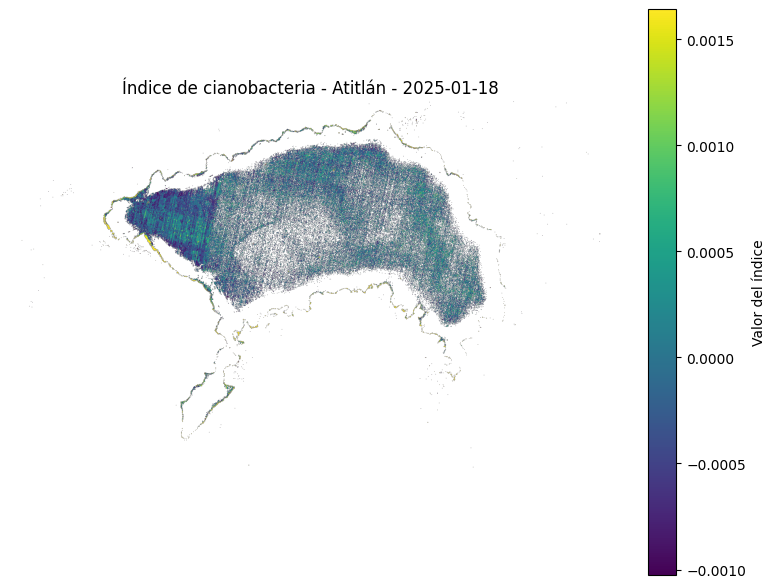

In [8]:
def mostrar_mapa(matriz, titulo, nombre_archivo, percentiles=(2, 98)):
    valores = matriz[np.isfinite(matriz)]

    if valores.size == 0:
        print(f"No hay valores válidos para: {titulo}")
        return

    vmin, vmax = np.nanpercentile(valores, percentiles)

    plt.figure(figsize=(8, 6))
    plt.imshow(matriz, vmin=vmin, vmax=vmax)
    plt.colorbar(label="Valor del índice")
    plt.title(titulo)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(GRAFICOS_DIR / nombre_archivo, dpi=180, bbox_inches="tight")
    plt.show()


mostrar_mapa(
    indices_prueba["cyano"],
    f"Índice de cianobacteria - {lago_prueba} - {fecha_prueba}",
    f"cyano_prueba_{nombre_seguro(lago_prueba)}_{fecha_prueba}.png"
)


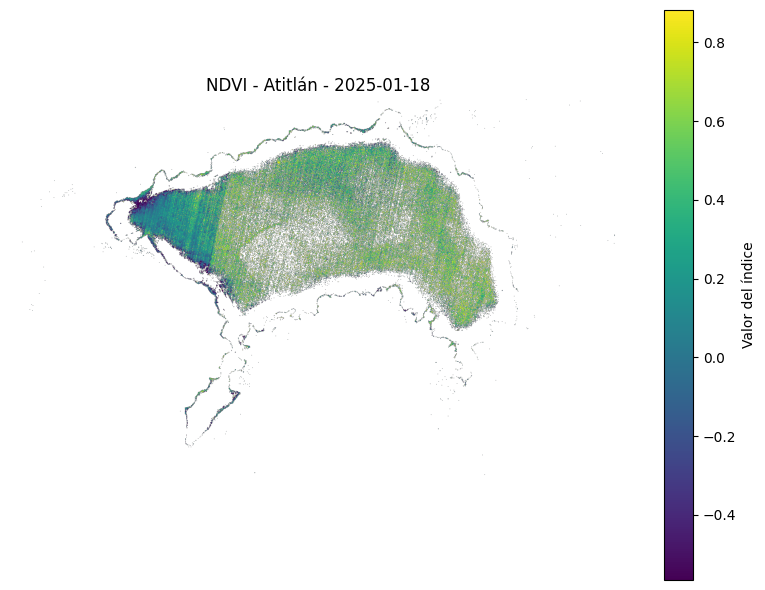

In [9]:
mostrar_mapa(
    indices_prueba["ndvi"],
    f"NDVI - {lago_prueba} - {fecha_prueba}",
    f"ndvi_prueba_{nombre_seguro(lago_prueba)}_{fecha_prueba}.png"
)


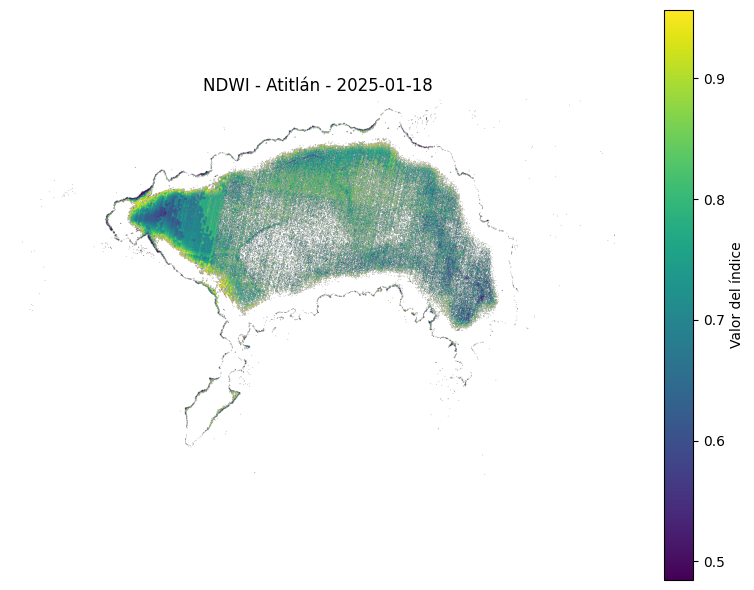

In [10]:
mostrar_mapa(
    indices_prueba["ndwi"],
    f"NDWI - {lago_prueba} - {fecha_prueba}",
    f"ndwi_prueba_{nombre_seguro(lago_prueba)}_{fecha_prueba}.png"
)


# Procesamiento de todas las fechas

Esta celda descarga cada fecha, calcula los índices y guarda una tabla con los promedios.

Si una fecha ya fue descargada, no se vuelve a bajar.

In [ ]:
registros = []

for lago, info in LAGOS.items():
    fechas = info["fechas"]
    if MAX_FECHAS is not None:
        fechas = fechas[:MAX_FECHAS]

    print(f"\nProcesando {lago}...")

    for fecha in tqdm(fechas):
        try:
            ruta = descargar_bandas_fecha(
                conn,
                lago,
                info["bbox"],
                fecha,
                resolucion=RESOLUCION_METROS
            )

            indices = leer_y_calcular_indices(ruta)

            cyano = indices["cyano"]
            ndvi = indices["ndvi"]
            ndwi = indices["ndwi"]

            validos_cyano = cyano[np.isfinite(cyano)]

            porcentaje_alto = (
                np.mean(validos_cyano > 0.05) * 100
                if validos_cyano.size > 0 else np.nan
            )

            registros.append({
                "lago": lago,
                "fecha": pd.Timestamp(fecha),
                "cyano_promedio": np.nanmean(cyano),
                "cyano_mediana": np.nanmedian(cyano),
                "ndvi_promedio": np.nanmean(ndvi),
                "ndwi_promedio": np.nanmean(ndwi),
                "porcentaje_cyano_alto": porcentaje_alto,
                "pixeles_validos": np.sum(np.isfinite(cyano)),
                "archivo": str(ruta)
            })

        except Exception as e:
            print(f"Error en {lago} - {fecha}: {e}")

resultados = pd.DataFrame(registros).sort_values(["lago", "fecha"]).reset_index(drop=True)

ruta_csv = RESULTADOS_DIR / "resumen_indices.csv"
resultados.to_csv(ruta_csv, index=False)

print("\nResultados guardados en:", ruta_csv)
resultados



Procesando Atitlán...


  0%|          | 0/11 [00:00<?, ?it/s]


Procesando Amatitlán...


  0%|          | 0/11 [00:00<?, ?it/s]

# Ejercicio 4. Análisis temporal

Primero se grafica el promedio del índice de cianobacteria por fecha para cada lago. Así se pueden identificar picos y cambios durante el período.

In [ ]:
def grafica_temporal_lago(df, lago):
    datos = df[df["lago"] == lago].sort_values("fecha").copy()

    if datos.empty:
        print(f"No hay datos para {lago}.")
        return

    pico = datos.loc[datos["cyano_promedio"].idxmax()]

    plt.figure(figsize=(10, 5))
    plt.plot(datos["fecha"], datos["cyano_promedio"], marker="o")
    plt.scatter([pico["fecha"]], [pico["cyano_promedio"]], s=90)
    plt.annotate(
        f"Pico: {pico['fecha'].date()}",
        (pico["fecha"], pico["cyano_promedio"]),
        xytext=(8, 10),
        textcoords="offset points"
    )
    plt.title(f"Evolución temporal del índice de cianobacteria - {lago}")
    plt.xlabel("Fecha")
    plt.ylabel("Índice promedio de cianobacteria")
    plt.grid(alpha=0.25)
    plt.xticks(rotation=45)
    plt.tight_layout()

    nombre = f"serie_temporal_{nombre_seguro(lago)}.png"
    plt.savefig(GRAFICOS_DIR / nombre, dpi=180, bbox_inches="tight")
    plt.show()


grafica_temporal_lago(resultados, "Atitlán")


In [ ]:
grafica_temporal_lago(resultados, "Amatitlán")


## Comparación visual de ambos lagos

Esta gráfica no sustituye las gráficas individuales, pero ayuda a ver rápidamente cuál lago tiene valores mayores en las fechas estudiadas.

In [ ]:
plt.figure(figsize=(10, 5))

for lago in ["Atitlán", "Amatitlán"]:
    datos = resultados[resultados["lago"] == lago].sort_values("fecha")
    if not datos.empty:
        plt.plot(datos["fecha"], datos["cyano_promedio"], marker="o", label=lago)

plt.title("Comparación temporal del índice de cianobacteria")
plt.xlabel("Fecha")
plt.ylabel("Índice promedio de cianobacteria")
plt.legend()
plt.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(GRAFICOS_DIR / "comparacion_temporal_lagos.png", dpi=180, bbox_inches="tight")
plt.show()


## Resumen automático de hallazgos

El siguiente bloque genera un análisis corto usando los resultados reales. No inventa fechas ni picos: los toma directamente de la tabla.

In [ ]:
def analizar_temporal(df):
    textos = []

    for lago in ["Atitlán", "Amatitlán"]:
        datos = df[df["lago"] == lago].dropna(subset=["cyano_promedio"]).sort_values("fecha").copy()

        if len(datos) < 2:
            textos.append(f"{lago}: no hay suficientes datos para analizar la tendencia.")
            continue

        pico = datos.loc[datos["cyano_promedio"].idxmax()]
        minimo = datos.loc[datos["cyano_promedio"].idxmin()]

        dias = (datos["fecha"] - datos["fecha"].min()).dt.days.to_numpy(dtype=float)
        valores = datos["cyano_promedio"].to_numpy(dtype=float)

        pendiente = np.polyfit(dias, valores, 1)[0] if np.ptp(dias) > 0 else 0.0
        cambio_estimado = pendiente * np.ptp(dias)
        rango = np.nanmax(valores) - np.nanmin(valores)

        if rango == 0 or abs(cambio_estimado) < 0.15 * rango:
            tendencia = "no muestra una tendencia clara y más bien fluctúa entre fechas"
        elif cambio_estimado > 0:
            tendencia = "muestra una tendencia general hacia valores más altos"
        else:
            tendencia = "muestra una tendencia general hacia valores más bajos"

        texto = (
            f"{lago}: el valor promedio más alto aparece el {pico['fecha'].date()} "
            f"con {pico['cyano_promedio']:.5f}. El valor más bajo aparece el "
            f"{minimo['fecha'].date()} con {minimo['cyano_promedio']:.5f}. "
            f"En general, la serie {tendencia}. "
            f"El porcentaje de agua con valores altos en la fecha del pico fue de "
            f"{pico['porcentaje_cyano_alto']:.2f}%."
        )
        textos.append(texto)

    return textos


resumen_textual = analizar_temporal(resultados)

for texto in resumen_textual:
    print("- " + texto)


### Interpretación ambiental

Los cambios entre fechas pueden estar relacionados con factores como temperatura, nutrientes disponibles, lluvia y escorrentía, circulación del agua o períodos de estancamiento.

Aun así, con las imágenes satelitales solas no se puede afirmar cuál fue la causa exacta de un pico. Lo que sí se puede hacer es detectar cuándo la señal aumenta, dónde aparece y qué tan fuerte es el cambio entre fechas.

# Mapas de las fechas con mayor promedio


In [ ]:
def mapa_fecha_pico(df, lago):
    datos = df[df["lago"] == lago].dropna(subset=["cyano_promedio"])
    if datos.empty:
        print(f"No hay datos para {lago}.")
        return

    fila = datos.loc[datos["cyano_promedio"].idxmax()]
    indices = leer_y_calcular_indices(fila["archivo"])

    mostrar_mapa(
        indices["cyano"],
        f"Mayor promedio de cianobacteria - {lago} - {fila['fecha'].date()}",
        f"mapa_pico_cyano_{nombre_seguro(lago)}.png"
    )


mapa_fecha_pico(resultados, "Atitlán")


In [ ]:
mapa_fecha_pico(resultados, "Amatitlán")


# Tabla final para el avance


In [ ]:
tabla_avance = resultados[
    [
        "lago",
        "fecha",
        "cyano_promedio",
        "cyano_mediana",
        "ndvi_promedio",
        "ndwi_promedio",
        "porcentaje_cyano_alto",
        "pixeles_validos"
    ]
].copy()

tabla_avance["fecha"] = tabla_avance["fecha"].dt.strftime("%Y-%m-%d")
tabla_avance
